### Práctica de transformer

  1. Entrenar un transformer con la función seno y predecir 50 valores subsiguientes.
  2. Entrenar un transformer con el precio diario de Apple (AAPL) y predecir 50 valores subsiguientes.


# Práctica 1: Deep Learning e IA Generativa

## Parte 2 — Predicción de secuencias con Transformer

### Integrantes
- Buendía Rodríguez Valentina
- López Méndez Emiliano
- Quinto Cesar

### Unidad de Aprendizaje
Aprendizaje Automático II

### Profesores
- Francisco Serradilla
- Raúl Lara

### Link de las conversaciones con Gemini
- Uso de IA para el desarrollo de la práctica -> [Pega aquí tu link]

https://gemini.google.com/share/5a5c32c3c294

## Descripción general de la práctica

En esta segunda parte de la práctica se trabajó con una arquitectura **Transformer** aplicada a problemas de predicción de secuencias. El objetivo principal fue analizar cómo este tipo de modelo, originalmente diseñado para tareas de procesamiento de lenguaje natural, también puede adaptarse al modelado de series temporales

Para cumplir con este propósito, primero se entrenó un Transformer sobre una señal senoidal, con la intención de que el modelo aprendiera su patrón periódico y fuera capaz de generar valores futuros. Posteriormente, la misma idea se trasladó a un problema más realista, utilizando datos históricos del precio diario de cierre de las acciones de Apple (AAPL) obtenidos con la librería `yfinance`

-------------------------------------------------------------------------------------------------------------------------------------------------

### Visualización de la onda seno y generación de los valores reales futuros

En esta sección se trabajó primero con la función seno original proporcionada en el ejemplo base del profesor. El propósito de esta parte fue **visualizar claramente el comportamiento de la señal** y tener una referencia del patrón periódico que el modelo debía aprender durante el entrenamiento

 se generó una extensión de la señal para obtener los **próximos 50 valores reales** ya que queriamos contar con una referencia verdadera con la cual comparar sus resultados

esta parte permitió construir el **escenario de comparación** entre:
- los valores reales de la función seno en el futuro, y
- los valores predichos por el Transformer.

##### Crea los datos de la función seno

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la onda seno
t = np.linspace(0, 100, 1000) # 1000 puntos de 0 a 100
data = np.sin(t).reshape(-1, 1)

# 2. Función para crear ventanas (Secuencias)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50 
X, y = create_sequences(data, seq_length)

# Convertir a Tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # para nvidia
print(device)
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

cpu


##### grafica de la onda seno

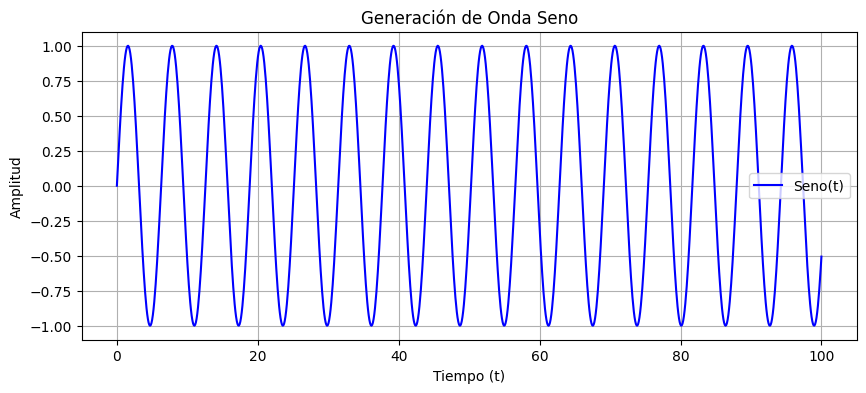

In [2]:
plt.figure(figsize=(10, 4))             
plt.plot(t, data, color='b', label='Seno(t)') 
plt.title('Generación de Onda Seno')   
plt.xlabel('Tiempo (t)')                
plt.ylabel('Amplitud')                 
plt.grid(True)                         
plt.legend()                            
plt.show()                            

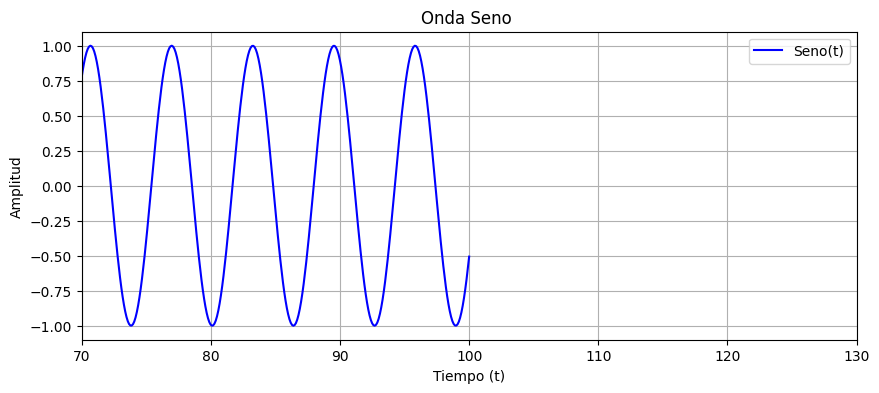

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(t, data, color='b', label='Seno(t)') 
plt.title('Onda Seno ')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.xlim(70, 130) 
plt.grid(True)
plt.legend()
plt.show()

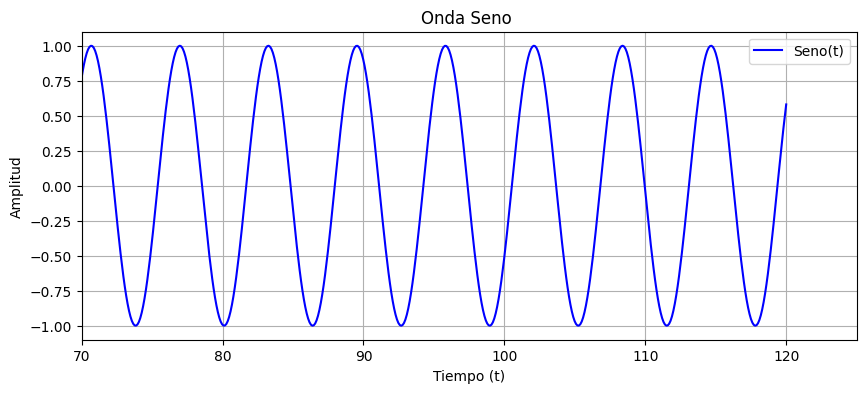

In [4]:
t_real = np.linspace(0, 120, 1200) 
data_real = np.sin(t_real).reshape(-1, 1)

plt.figure(figsize=(10, 4))
plt.plot(t_real, data_real, color='b', label='Seno(t)') 
plt.title('Onda Seno ')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.xlim(70, 125) 
plt.grid(True)
plt.legend()
plt.show()


#### Codificación posicional

Para resolver ese problema se definió la clase `PositionalEncoding`. Su función fue añadir información de posición a cada elemento de la secuencia. Esto se hizo usando funciones seno y coseno, fue para que el modelo pudiera distinguir el orden temporal de los datos

Dentro de esta clase, el parámetro `d_model` representa el tamaño interno de la representación del modelo. También se definió `max_len=5000` para asegurar que exista suficiente espacio para manejar secuencias relativamente largas sin tener que recalcular estas posiciones cada vez

Después, en el método `forward`, la codificación posicional se suma directamente a los datos de entrada transformados. La intención de esto fue combinar la información del valor numérico con la información de su posición en el tiempo, para que el modelo no solo vea amplitudes, sino también el lugar que ocupan dentro de la secuencia

#### Estructura principal del Transformer

El primer componente de esta clase es `input_projection = nn.Linear(input_dim, d_model)`. La intención de esta capa fue transformar la entrada original a un espacio interno más grande (`d_model=32`). Esto ayuda al modelo a representar mejor la información antes de pasarla al bloque Transformer

#### Capa encoder del Transformer

- `d_model = 32`: se eligió un tamaño moderado para que el modelo tuviera suficiente capacidad para aprender patrones
- `nhead = 4`: esto significa que la atención se divide en 4 cabezas, una cabeza puede enfocarse en cierta parte del patrón mientras otra aprende otro tipo de relación
- `num_layers = 2`: se usaron dos capas encoder para que el modelo pudiera captar relaciones más profundas sin complicar demasiado la arquitectura
- `dim_feedforward = 64`: esta parte controla el tamaño de la red interna de cada bloque encoder. Se eligió un valor mayor que `d_model` para darle más capacidad de transformación a la red
- `dropout = 0.1`: se añadió para evitar que el modelo dependa demasiado de ciertas conexiones y así mejorar un poco la generalización

Después, con `nn.TransformerEncoder`, se apilaron estas capas para formar el encoder completo

#### Capa de salida

se toma únicamente la última posición con la instrucción:

`x = x[:, -1, :]`

se aplica `self.fc_out = nn.Linear(d_model, 1)`, que convierte esa representación interna en un solo valor de salida. Ese valor corresponde a la predicción del siguiente punto de la serie

##### Define la red completa

In [5]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  
        self.register_buffer('pe', pe)

    def forward(self, x):
        
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return x


class SequenceTransformer(nn.Module):
    def __init__(self, input_dim=1, d_model=32, nhead=4, num_layers=2, dim_feedforward=64, dropout=0.1):
        super().__init__()
        
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        
        x = self.input_projection(x)         
        x = self.pos_encoder(x)              
        x = self.transformer_encoder(x)      
        
        x = x[:, -1, :]                      
        out = self.fc_out(x)                 
        
        return out

#### Función de pérdida y optimizador

se definió el modelo con:

`model = SequenceTransformer().to(device)`

`optimizer = torch.optim.Adam(model.parameters(), lr=0.001)`

Se eligió el optimizador Adam porque suele funcionar bien en redes neuronales profundas y ajusta los pesos de manera eficiente

`criterion = nn.MSELoss()`

La función de pérdida MSE (Mean Squared Error) se eligió porque el problema es de regresión

In [6]:
model = SequenceTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model

SequenceTransformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=32, out_features=1, bias=True)
)

### Entrenamiento del modelo

En esta etapa se llevó a cabo el entrenamiento del Transformer utilizando la secuencia de datos generada previamente a partir de la onda seno

Primero se definió una lista llamada `losses`, en donde se fueron guardando los valores de pérdida obtenidos en cada época. Esto se hizo para poder observar después cómo fue evolucionando el entrenamiento y verificar si el modelo realmente estaba aprendiendo. También se estableció `epochs = 100`, que corresponde al número de veces que el modelo recorrería todo el conjunto de datos durante el proceso de ajuste

Después, los datos `X` y `y` se convirtieron a tensores con tipo `float32` y se enviaron al dispositivo disponible. La intención de esto fue asegurar que tanto las entradas como las salidas estuvieran en el formato correcto para trabajar con PyTorch y que el entrenamiento pudiera ejecutarse en CPU o GPU, se activó el modo de entrenamiento con `model.train()`. 

Dentro del ciclo principal, que recorre cada época, se utilizó primero `optimizer.zero_grad()`. La intención de esta instrucción fue reiniciar los gradientes antes de calcular unos nuevos, ya que en PyTorch estos se acumulan si no se limpian manualmente

Luego se obtuvo la salida del modelo con `output = model(X_batch)`. En este paso, la secuencia de entrada se pasa por toda la arquitectura Transformer para generar la predicción. Después se calculó la pérdida con `loss = criterion(output, y_batch)`, comparando los valores predichos con los valores reales. Esta pérdida representa qué tan lejos está el modelo de la respuesta correcta

Se aplicó `loss.backward()`, que permite calcular los gradientes de todos los parámetros de la red con respecto al error obtenido. Después se ejecutó `optimizer.step()`, cuya función es actualizar los pesos del modelo para reducir la pérdida en la siguiente iteración

En cada época también se guardó el valor del error en la lista `losses`, para construir una gráfica para visualizar la evolución del entrenamiento

Se generó una gráfica de la evolución del error para visualizar si el loss disminuía con el paso de las épocas

##### Entrena

C:\Users\HP\AppData\Local\Temp\ipykernel_20472\2881462798.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_batch = torch.tensor(X, dtype=torch.float32).to(device)
C:\Users\HP\AppData\Local\Temp\ipykernel_20472\2881462798.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_batch = torch.tensor(y, dtype=torch.float32).to(device)


Epoch [10/100], Loss: 0.364276
Epoch [20/100], Loss: 0.033236
Epoch [30/100], Loss: 0.044595
Epoch [40/100], Loss: 0.022133
Epoch [50/100], Loss: 0.016702
Epoch [60/100], Loss: 0.015679
Epoch [70/100], Loss: 0.013974
Epoch [80/100], Loss: 0.011499
Epoch [90/100], Loss: 0.010995
Epoch [100/100], Loss: 0.011113


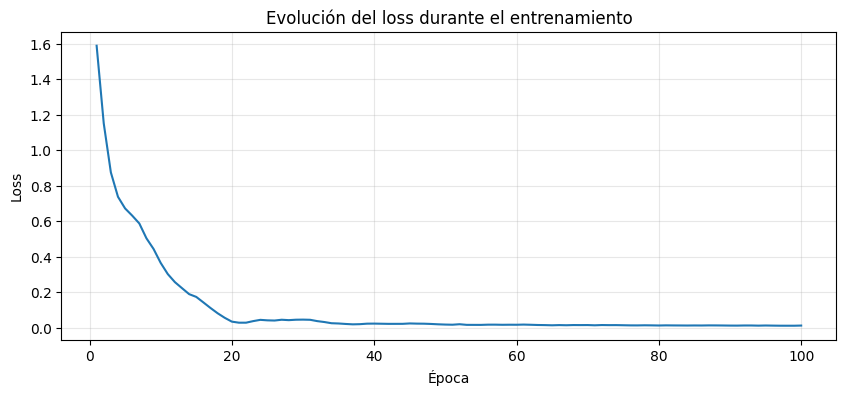

In [7]:
# TO-DO
losses = []
epochs = 100

X_batch = torch.tensor(X, dtype=torch.float32).to(device)
y_batch = torch.tensor(y, dtype=torch.float32).to(device)

model.train()


for epoch in range(epochs):

    optimizer.zero_grad()
    
    # Le pasamos los tensores
    output = model(X_batch)
    loss = criterion(output, y_batch)
        
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")
        
plt.figure(figsize=(10,4))
plt.plot(range(1, epochs + 1), losses)
plt.title("Evolución del loss durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

A partir de la gráfica de entrenamiento se puede observar que el valor del loss disminuye de manera considerable conforme avanzan las épocas. Se puede ver que el Transformer logró ajustarse de forma correcta a la secuencia y aprender la relación entre los puntos pasados y el siguiente valor

Además, la forma de la curva sugiere que el entrenamiento fue estable, ya que no se observan oscilaciones bruscas ni aumentos inesperados del error

### Métricas de evaluación


- **MAE (Mean Absolute Error)**: mide el error absoluto promedio entre las predicciones y los valores reales. Su intención es mostrar, de forma directa y fácil de interpretar, cuánto se equivoca en promedio el modelo en cada predicción

- **RMSE (Root Mean Squared Error)**: representa la raíz del error cuadrático medio. Esta métrica también mide qué tan lejos están las predicciones de los valores reales, pero penaliza más los errores grandes

- **R² (coeficiente de determinación)**: indica qué proporción de la variabilidad de los datos reales es explicada por el modelo. Su intención es medir qué tan bien la predicción sigue el comportamiento general de la serie. Un valor cercano a 1 indica un ajuste muy bueno

En conjunto, estas métricas complementan al loss, ya que permiten evaluar el modelo desde distintos puntos de vista: error promedio, sensibilidad a errores grandes y capacidad de explicar la forma general de la señal.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()

with torch.no_grad():
    y_pred = model(X_batch)

# Pasar a numpy
y_real = y_batch.cpu().numpy()
y_pred = y_pred.cpu().numpy()

# Calcular métricas
mae = mean_absolute_error(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_real, y_pred)

print(f"MAE : {mae:.6f}")
print(f"MSE : {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.039714
MSE : 0.002033
RMSE: 0.045087
R²  : 0.995942


El valor de **MAE = 0.039714** indica que, en promedio, el error absoluto de las predicciones fue pequeño, el **RMSE = 0.045087** también resultó bajo, lo que muestra que el modelo no presentó errores grandes de manera frecuente y el valor de **R² = 0.995942** se encuentra muy cercano a 1, lo cual significa que el Transformer explicó casi toda la variación de la señal real

##### Calcula los puntos siguientes

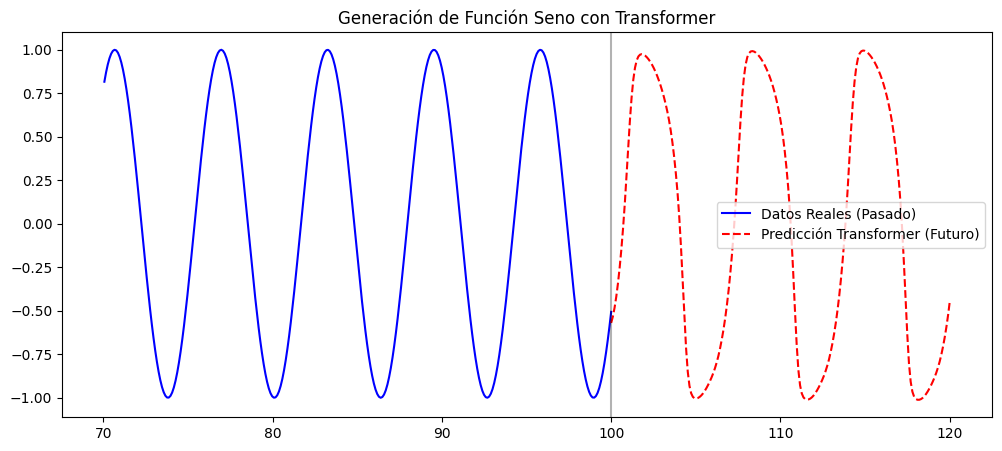

In [9]:
model.eval()
future_points = 200
predictions = []

# Tomamos la última ventana de los datos reales para empezar
last_sequence = X[-1].unsqueeze(0) 

for _ in range(future_points):
    with torch.no_grad():
        pred = model(last_sequence) # Predice el siguiente punto
        predictions.append(pred.item())
        
        # Actualizamos la ventana: desplazamos y añadimos la predicción
        new_row = pred.unsqueeze(1) 
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_row), dim=1)

# Pintar resultados
plt.figure(figsize=(12,5))
plt.plot(t[-300:], data[-300:], label="Datos Reales (Pasado)", color="blue")
plt.plot(np.linspace(t[-1], t[-1]+20, future_points), predictions, label="Predicción Transformer (Futuro)", linestyle="--", color="red")
plt.axvline(x=t[-1], color='black', alpha=0.3)
plt.legend()
plt.title("Generación de Función Seno con Transformer")
plt.show()

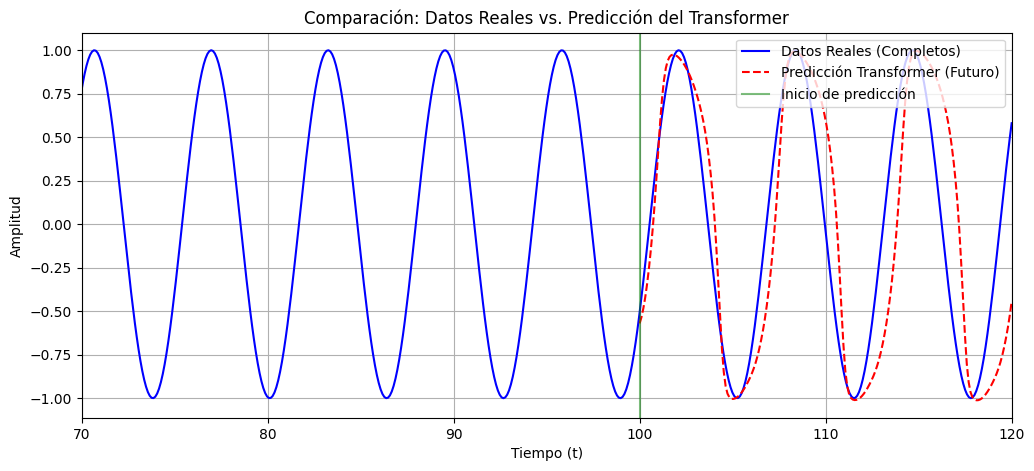

In [10]:
plt.figure(figsize=(12, 5))

# 1. Graficar TODOS los datos reales (pasado y futuro real)
plt.plot(t_real, data_real, color='blue', label='Datos Reales (Completos)')

# 2. Recrear el eje X para las predicciones (basado en tu código del Transformer)
t_preds = np.linspace(t[-1], t[-1] + 20, future_points)

# 3. Graficar las predicciones del Transformer superpuestas
plt.plot(t_preds, predictions, color='red', linestyle='--', label='Predicción Transformer (Futuro)')

# 4. Añadir una línea vertical para marcar dónde empieza el futuro
plt.axvline(x=t[-1], color='green', alpha=0.5, label='Inicio de predicción')

plt.xlim(70, 120) 

plt.title('Comparación: Datos Reales vs. Predicción del Transformer')
plt.xlabel('Tiempo (t)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend(loc='upper right') 
plt.show()

### Comparación entre los datos reales y la predicción del Transformer

Buscamos comparar de manera visual el comportamiento de la señal real con la secuencia generada por el Transformer, se añadió una línea vertical para marcar el punto exacto en el que termina la información conocida y comienza la predicción futura para poder distinguir claramente qué parte corresponde a datos reales usados como referencia y cuál corresponde a valores generados por el Transformer

Gracias a esta comparación, fue posible evaluar visualmente si el modelo logró conservar la periodicidad, la amplitud y la forma general de la onda seno

### Acciones de Apple

In [11]:
%pip install --upgrade yfinance

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Preparación de los datos de Apple

En esta sección se descargaron los datos históricos de la acción de Apple utilizando la librería `yfinance`. De toda la información disponible, se trabajó únicamente con el precio de cierre (`Close`), ya que este valor resume el comportamiento final de la acción en cada día y es una de las variables más utilizadas en problemas de predicción financiera

Después, los datos se normalizaron en un rango de 0 a 1 mediante `MinMaxScaler`, ya que las redes neuronales suelen funcionar mejor cuando los valores de entrada están en una escala

El modelo toma como entrada los 60 valores anteriores para intentar predecir el siguiente, fue para  convertir la serie temporal en un problema supervisado, donde cada bloque de datos pasados tiene asociado un valor objetivo

Finalmente, estas secuencias se convirtieron a tensores de PyTorch para que pudieran ser procesadas por la red neuronal durante el entrenamiento

In [12]:
# Descargar datos
df = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
data = df['Close'].values.reshape(-1, 1)

# Normalización (Importante para Transformers)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

# Función para crear secuencias
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 60 # Usamos 60 días previos para predecir el siguiente
X, y = create_sequences(data_scaled, seq_length)

# Convertir a Tensores de PyTorch
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

print(f"Forma de X: {X.shape}") # [muestras, seq_length, 1]

[*********************100%***********************]  1 of 1 completed

Forma de X: torch.Size([1448, 60, 1])


### Visualización inicial de los datos de Apple

Se construyó una gráfica del precio de cierre de Apple usando las fechas como eje horizontal,esta visualización fue para observar de manera general cómo se ha comportado la acción a lo largo del tiempo y entender mejor la naturaleza de la serie temporal

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400536  72.460799  71.156697  71.409800  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267914  72.306483  70.568488  70.819186  118387200
2020-01-07  71.928040  72.533080  71.708680  72.277563  108872000
2020-01-08  73.085114  73.386431  71.631559  71.631559  132079200


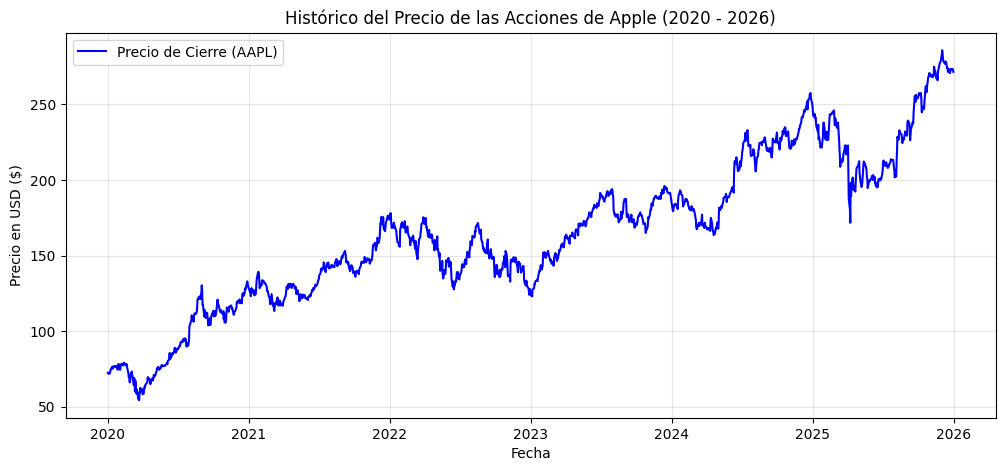

In [13]:
# Ver primeras filas
print(df.head())

plt.figure(figsize=(12, 5))

# Graficar los datos usando el índice (fechas) y la columna 'Close'
plt.plot(df.index, df['Close'], color='blue', label='Precio de Cierre (AAPL)')

# Personalizar el gráfico
plt.title('Histórico del Precio de las Acciones de Apple (2020 - 2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD ($)')
plt.grid(True, alpha=0.3)  # alpha hace que la cuadrícula sea más suave
plt.legend()

# Mostrar la gráfica
plt.show()

#### Codificación posicional

Primero se construyó la clase `PositionalEncodingApple` para agregar información sobre la posición de cada dato dentro de la secuencia

Para lograrlo, se usaron funciones seno y coseno. De esta manera, el modelo no solo recibe los valores del precio, sino también una referencia de su orden dentro de los 60 días observados, se incluyó `dropout` para ayudar a que el modelo no dependa demasiado de ciertas representaciones internas durante el entrenamiento

#### Proyección de entrada

Dentro de la clase `TimeSeriesTransformer`, la primera capa es `self.input_projection = nn.Linear(input_size, d_model)`. La intención de esta parte fue transformar la entrada original, que solo tiene un valor por día, a una representación interna más de tamaño `d_model = 64`. Esto permite que el modelo trabaje con más características internas y tenga mayor capacidad para aprender patrones temporales

#### Bloques encoder del Transformer

Después se definió `encoder_layer` con `nn.TransformerEncoderLayer` con los siguientes parámetros:

- **`d_model = 64`**: se eligió un tamaño mayor para darle al modelo más capacidad de representación
- **`nhead = 4`**: se usaron 4 cabezas de atención para que el modelo pudiera analizar distintas relaciones dentro de la secuencia al mismo tiempo
- **`num_layers = 3`**: se apilaron tres capas encoder para que el Transformer pudiera aprender relaciones un poco más profundas
- **`dim_feedforward = d_model * 4`**: se aumentó el tamaño de la red interna de cada bloque para darle mayor capacidad de transformación
- **`dropout = 0.15`**: se agregó una pequeña regularización para evitar que el modelo se ajuste demasiado a ciertos patrones del entrenamiento
- **`activation = 'gelu'`**: se utilizó esta activación porque suele funcionar bien en modelos tipo Transformer, ya que permite transiciones más suaves que ReLU

Después, todos estos bloques se apilaron dentro de `self.transformer_encoder`

#### Centrando la ventana respecto al último valor

En el método `forward`,  tomamamos el último valor real de la ventana con:

`last_val = x[:, -1, :]`

y después centrar toda la secuencia respecto a ese valor:

`x_centered = x - last_val.unsqueeze(1)`

Esto fue para que el modelo no se enfocara tanto en el nivel absoluto del precio, sino más bien en las variaciones recientes alrededor del último dato conocido

#### Extracción de información de la secuencia

Después de pasar la secuencia proyectada y codificada por el encoder, se obtienen dos representaciones importantes:

- `last_token`: representa la información de la última posición de la ventana
- `mean_token`: representa un resumen promedio de toda la secuencia

Esto ayuda a que la predicción no dependa solamente del último día, sino también del contexto general de los 60 días anteriores

#### Cabeza final y predicción residual

 `self.head`, compuesta por:

- `LayerNorm`
- una capa lineal
- activación `GELU`
- `Dropout`
- y una última capa lineal

fue para refinar la información extraída por el Transformer antes de producir la salida final.

En lugar de predecir directamente el siguiente precio completo, el modelo aprende un **delta** o cambio:

`delta = self.head(features)`

y después construye la salida como:

`out = last_val + delta`

Fue para que el modelo aprendiera cuánto debería moverse el precio respecto al último valor conocido, en vez de obligarlo a reconstruir desde cero un precio complet

In [14]:
class PositionalEncodingApple(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncodingApple, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=3, dropout=0.15):
        super(TimeSeriesTransformer, self).__init__()

        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncodingApple(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)

        # Último valor real de la ventana
        last_val = x[:, -1, :]  

        # Centramos la ventana respecto al último valor
        x_centered = x - last_val.unsqueeze(1)

        x_proj = self.input_projection(x_centered)
        x_pos = self.pos_encoder(x_proj)
        x_enc = self.transformer_encoder(x_pos)

        last_token = x_enc[:, -1, :]
        mean_token = x_enc.mean(dim=1)

        features = torch.cat([last_token, mean_token], dim=1)

        delta = self.head(features)

        out = last_val + delta
        return out


#### Función de pérdida, optimizador y scheduler

- **`criterion_apple = nn.HuberLoss()`**  
  Se eligió Huber Loss porque combina ventajas del MAE y del MSE

- **`optimizer_apple = torch.optim.AdamW()`**  
  Se utilizó AdamW en lugar de Adam normal porque maneja mejor la regularización mediante `weight_decay`

- **`lr = 3e-4`**  
  Se escogió una tasa de aprendizaje pequeña para que el ajuste fuera más fino y menos agresivo

- **`weight_decay = 1e-4`**  
  Se añadió esta regularización para evitar que el modelo dependa demasiado de ciertos pesos y así favorecer una mejor generalización

- **`scheduler_apple = ReduceLROnPlateau()`**  
  Se incluyó un scheduler para reducir automáticamente la tasa de aprendizaje cuando la pérdida deje de mejorar

In [15]:
model_apple = TimeSeriesTransformer().to(device)

criterion_apple = nn.HuberLoss()
optimizer_apple = torch.optim.AdamW(model_apple.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_apple = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_apple, mode='min', factor=0.5, patience=5
)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### Entrenamiento del Transformer para Apple

Los tensores `X` y `y` se pasaron a CPU para poder dividirlos en tres conjuntos: 
-   entrenamiento
-   validación
-   prueba 

Fue para que el modelo no se evaluara únicamente sobre los mismos datos con los que aprende, sino también sobre datos que no ha visto durante el ajuste. Para esta práctica se utilizó una división de 70% para entrenamiento, 15% para validación y 15% para prueba

Después, se usó `TensorDataset` junto con `DataLoader` para organizar mejor los datos en lotes (`batch_size=32`). La intención de trabajar por lotes fue hacer el entrenamiento más ordenado y estable, además de permitir que el modelo actualizara sus pesos varias veces por época en lugar de usar todo el conjunto de una sola vez

##### entrenar

In [16]:
from torch.utils.data import TensorDataset, DataLoader
import copy

X_cpu = X.detach().cpu()
y_cpu = y.detach().cpu()

n = len(X_cpu)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_cpu[:train_end]
y_train = y_cpu[:train_end]

X_val = X_cpu[train_end:val_end]
y_val = y_cpu[train_end:val_end]

X_test = X_cpu[val_end:]
y_test = y_cpu[val_end:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([1013, 60, 1]) torch.Size([1013, 1])
Val: torch.Size([217, 60, 1]) torch.Size([217, 1])
Test: torch.Size([218, 60, 1]) torch.Size([218, 1])


Durante cada época, el modelo se colocó en modo entrenamiento con `model_apple.train()`. Luego, para cada lote, se enviaron los datos al dispositivo correspondiente y se reiniciaron los gradientes con `optimizer_apple.zero_grad()`. Después se calculó la predicción del modelo, se comparó con los valores reales usando la función de pérdida y se realizó el proceso de retropropagación con `loss.backward()` para ajustar los pesos

También se aplicó `clip_grad_norm_`, cuya intención fue limitar el tamaño de los gradientes y evitar actualizaciones demasiado grandes que pudieran volver inestable el entrenamiento. Finalmente, con `optimizer_apple.step()` se actualizaron los parámetros del modelo

Al terminar cada época, además del error de entrenamiento, se calculó el error de validación usando `model_apple.eval()` y `torch.no_grad()`. La intención de esta parte fue monitorear qué tan bien generalizaba el modelo sobre datos no vistos durante el ajuste

Se utilizó un mecanismo de **early stopping** para evitar entrenamiento innecesario y reducir el riesgo de sobreajuste. De igual forma, se guardó el mejor estado del modelo con base en el menor `val_loss`, para asegurarse de conservar la versión que tuvo mejor desempeño en validación

Finalmente, se graficaron las curvas de `train loss` y `validation loss` para observar si el modelo estaba aprendiendo de manera estable y si existía una diferencia importante entre entrenamiento y validación.

Epoch [10/120] | Train Loss: 0.000272 | Val Loss: 0.000111
Epoch [20/120] | Train Loss: 0.000172 | Val Loss: 0.000105
Epoch [30/120] | Train Loss: 0.000142 | Val Loss: 0.000102
Epoch [40/120] | Train Loss: 0.000141 | Val Loss: 0.000102
Early stopping activado


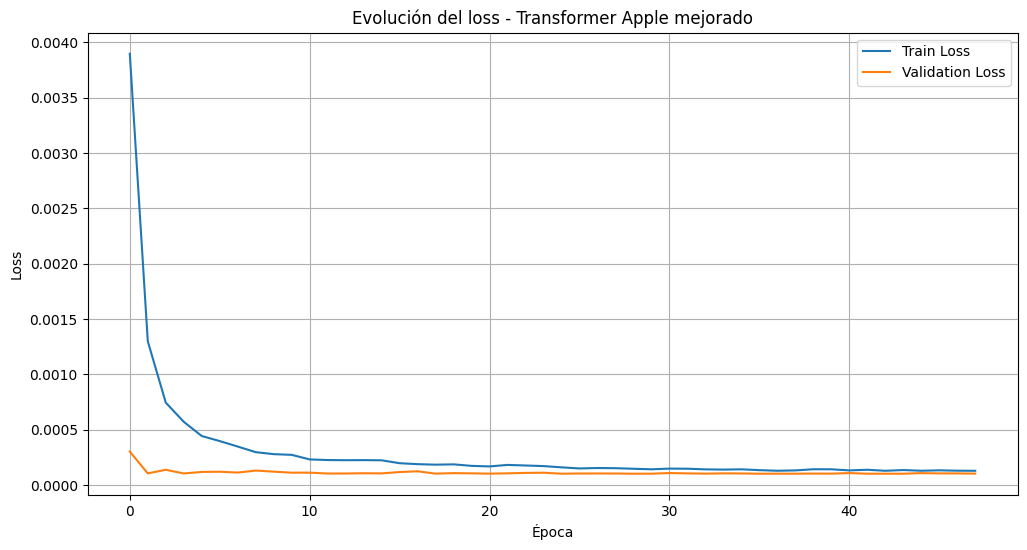

In [ ]:
epochs = 120
patience = 12

train_losses_apple = []
val_losses_apple = []

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(epochs):
    model_apple.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_apple.zero_grad()
        preds = model_apple(xb)
        loss = criterion_apple(preds, yb)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_apple.parameters(), max_norm=1.0)
        optimizer_apple.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses_apple.append(avg_train_loss)

    model_apple.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model_apple(xb)
            loss = criterion_apple(preds, yb)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses_apple.append(avg_val_loss)

    scheduler_apple.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model_apple.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    if patience_counter >= patience:
        print("Early stopping activado")
        break

model_apple.load_state_dict(best_model_state)

plt.figure(figsize=(12,6))
plt.plot(train_losses_apple, label="Train Loss")
plt.plot(val_losses_apple, label="Validation Loss")
plt.title("Evolución del loss - Transformer Apple mejorado")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la evolución del loss

En esta gráfica se observa que tanto el **train loss** como el **validation loss** disminuyen con rapidez durante las primeras épocas y después se estabilizan en valores muy bajos. Esto indica que el modelo logró aprender patrones útiles de la serie temporal de Apple desde las primeras iteraciones

También se puede notar que la curva de validación se mantiene muy cercana a la de entrenamiento e incluso empieza un poco más abajo. Esto puede ocurrir porque en entrenamiento el modelo trabaja con regularización como `dropout`, mientras que en validación la evaluación se hace de forma más directa, el uso de **early stopping** permitió detener el entrenamiento en el momento adecuado

### Métricas de evaluación del modelo

In [18]:
model_apple.eval()

preds_test = []
real_test = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model_apple(xb).cpu().numpy()
        preds_test.append(preds)
        real_test.append(yb.numpy())

preds_test = np.vstack(preds_test)
real_test = np.vstack(real_test)

# Métricas en escala normalizada
mae = mean_absolute_error(real_test, preds_test)
mse = mean_squared_error(real_test, preds_test)
rmse = np.sqrt(mse)
r2 = r2_score(real_test, preds_test)

print(f"MAE  : {mae:.6f}")
print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

MAE  : 0.012047
MSE  : 0.000348
RMSE : 0.018649
R²   : 0.976666


El valor de **MAE = 0.012047** indica que, en promedio el error absoluto de las predicciones fue pequeño, el **MSE = 0.000348** y el **RMSE = 0.018649** también resultaron bajos, lo cual sugiere que el modelo no presentó errores grandes de manera frecuente y que su nivel de desviación general fue reducido

Finalmente, el valor de **R² = 0.976666** se encuentra bastante cercano a 1, lo que indica que el modelo fue capaz de explicar gran parte de la variación presente en la serie

### Predicción futura de 50 días para Apple

En esta parte se utilizó el modelo ya entrenado para generar una proyección de los siguientes 50 valores del precio de cierre de Apple. Para hacerlo, se tomó la última secuencia conocida de 60 días y, a partir de ella, el Transformer predijo el siguiente valor. Después, esa nueva predicción se agregó al final de la ventana y el proceso se repitió varias veces hasta completar los 50 días futuros

In [19]:
model_apple.eval()
future_predictions = []
current_batch = X[-1].unsqueeze(0) # Tomamos la última secuencia conocida

for _ in range(50):
    with torch.no_grad():
        pred = model_apple(current_batch)
        future_predictions.append(pred.item())
        
        # Actualizar la ventana: quitar el primero, añadir la predicción al final
        new_pred = pred.unsqueeze(1) # [1, 1, 1]
        current_batch = torch.cat((current_batch[:, 1:, :], new_pred), dim=1)

# Des-normalizar los resultados
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

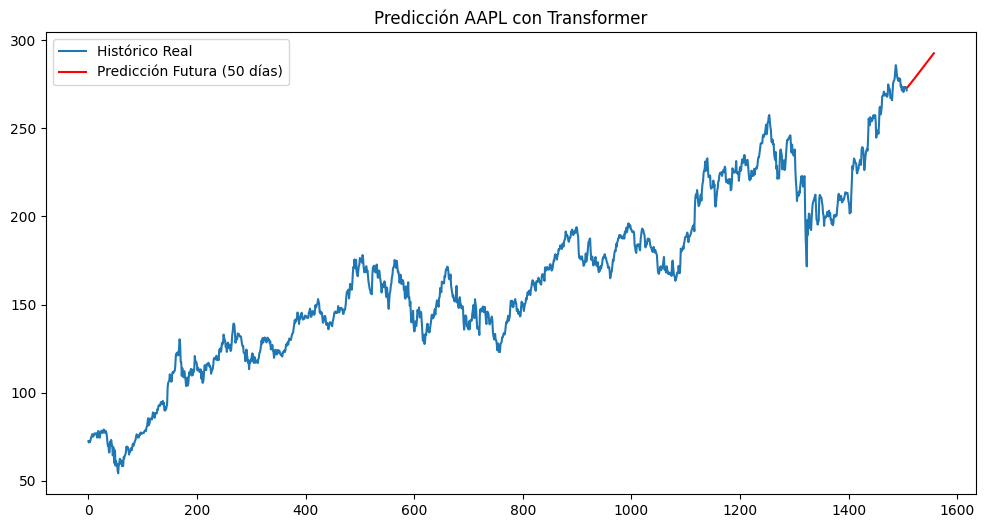

In [20]:
plt.figure(figsize=(12,6))
plt.plot(range(len(data)), scaler.inverse_transform(data_scaled), label='Histórico Real')
plt.plot(range(len(data), len(data) + 50), future_predictions, label='Predicción Futura (50 días)', color='red')
plt.title('Predicción AAPL con Transformer')
plt.legend()
plt.show()

## Conclusiones 

El Transformer logró reproducir con buena aproximación la forma periódica de la señal, manteniendo la amplitud y la tendencia general de la secuencia. Esto confirmó que el modelo fue capaz de captar relaciones temporales claras en un entorno controlado, al aplicarlo a los datos históricos de Apple, se observó un escenario más complejo, donde la serie presenta ruido, cambios abruptos y menor regularidad. Aun así, el modelo mostró un desempeño sólido durante el entrenamiento, con pérdidas bajas, una validación estable y métricas de evaluación favorables, lo que indica que sí logró aprender parte de la dinámica de la serie.